#Face Recognition with CNN (Olivetti Dataset)

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models

In [38]:
# 1. Load Data (Olivetti Faces)
print("Loading Olivetti Faces dataset...")
data = fetch_olivetti_faces()
images = data.images
targets = data.target

print(f"Total Images: {images.shape[0]}")
print(f"Image Size: {images.shape[1]}x{images.shape[2]}")
print(f"Number of People (Classes): {len(np.unique(targets))}")

Loading Olivetti Faces dataset...
Total Images: 400
Image Size: 64x64
Number of People (Classes): 40


In [39]:
# 2. Preprocessing
X = images.reshape(-1, 64, 64, 1)
y = targets

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")



Training shape: (320, 64, 64, 1)
Testing shape: (80, 64, 64, 1)


In [40]:
# 3.CNN Architecture
model = models.Sequential([
    # Layer 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    layers.MaxPooling2D((2, 2)),

    # Layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layer 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(40, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687,784 (2.62 MB)

 Trainable params: 687,784 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# 4. Train the Model
print("\nStarting training...")
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=1)


Starting training...
Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.0059 - loss: 3.7129 - val_accuracy: 0.0250 - val_loss: 3.6880
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0273 - loss: 3.6900 - val_accuracy: 0.0250 - val_loss: 3.6872
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0406 - loss: 3.6855 - val_accuracy: 0.0250 - val_loss: 3.6846
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0275 - loss: 3.6860 - val_accuracy: 0.0500 - val_loss: 3.6824
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0267 - loss: 3.6829 - val_accuracy: 0.0625 - val_loss: 3.6718
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0775 - loss: 3.6646 - val_accuracy: 0.0625 - val_loss: 3.6306
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0726 - loss: 3.6138 - val_accuracy: 0.1250 - val_loss: 3.5298
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0777 - loss: 3.


--- Model Evaluation ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step
Test Accuracy: 97.50%


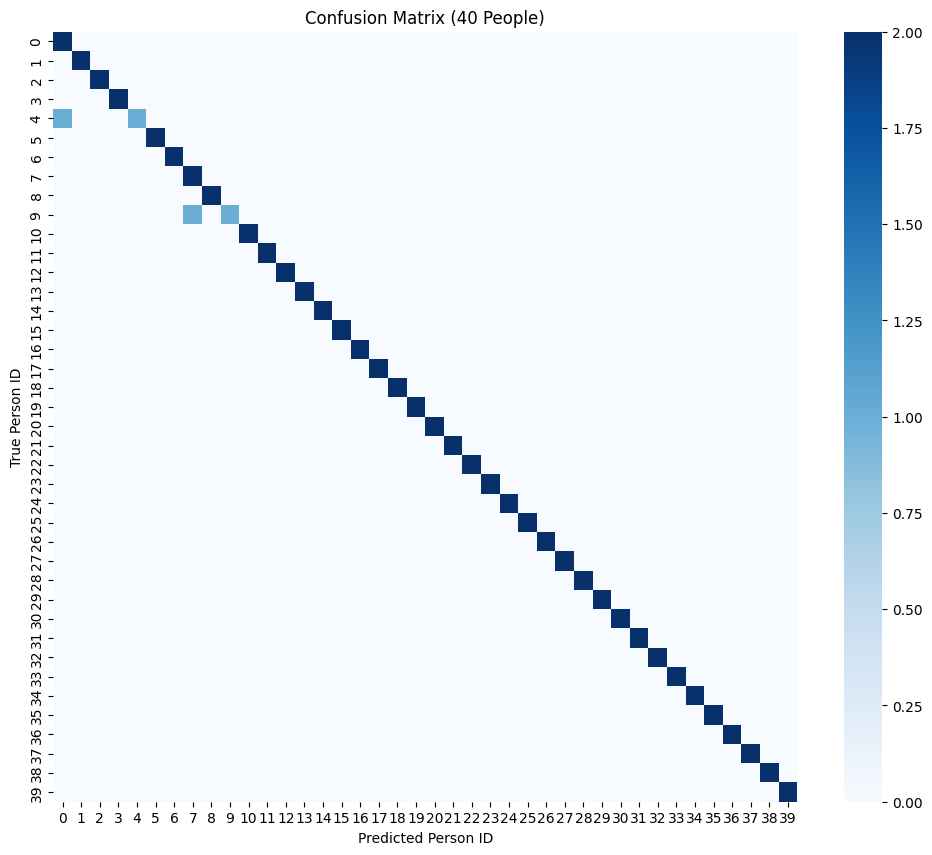

In [42]:
# 5. Evaluate the Model
print("\n--- Model Evaluation ---")
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc*100:.2f}%")


# Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, cmap='Blues', annot=False)
plt.title('Confusion Matrix (40 People)')
plt.ylabel('True Person ID')
plt.xlabel('Predicted Person ID')
plt.show()

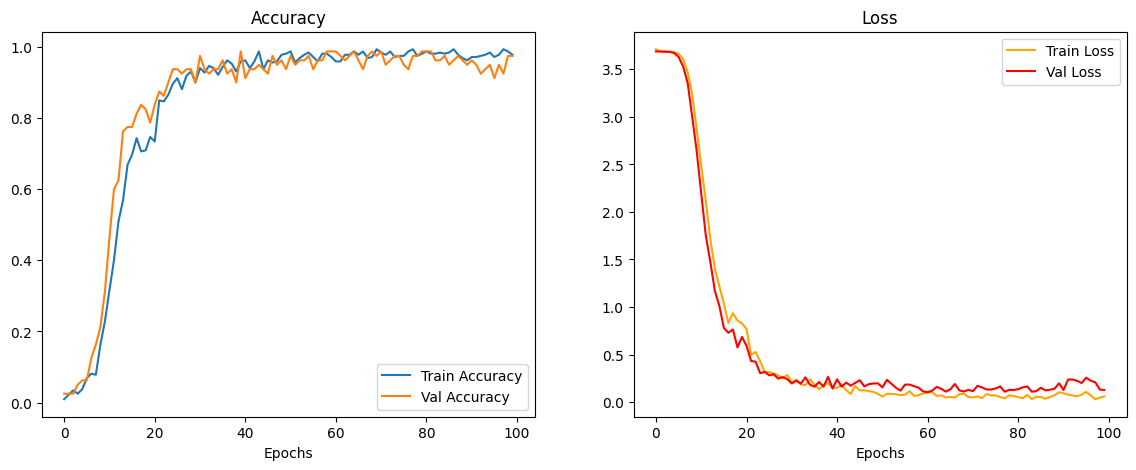

In [43]:
# 6. Visualization
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='orange')
plt.plot(history.history['val_loss'], label='Val Loss', color='red')
plt.title('Loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()


--- Prediction Samples ---


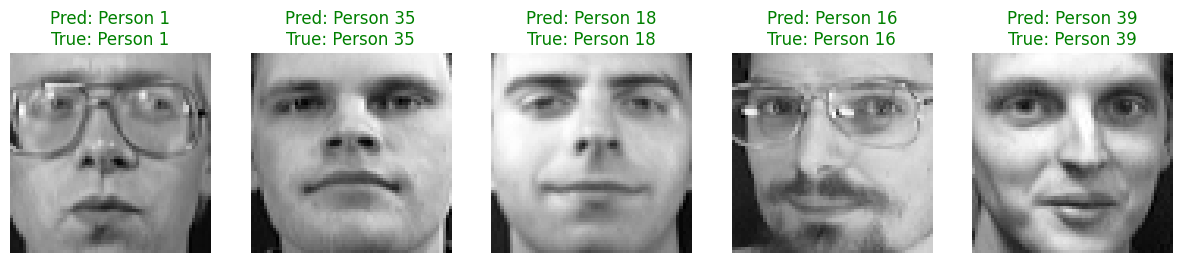

In [44]:
# Show some actual predictions
print("\n--- Prediction Samples ---")
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i].reshape(64, 64), cmap='gray')
    pred_label = y_pred[i]
    true_label = y_test[i]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: Person {pred_label}\nTrue: Person {true_label}", color=color)
    ax.axis('off')
plt.show()

In [45]:
from google.colab import files

# Save the entire model (architecture + weights + optimizer state)
model.save('face_cnn_model.h5')
print("Model saved successfully as 'face_cnn_model.h5'")

Model saved successfully as 'face_cnn_model.h5'
